In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
(x_train,y_train), (x_test,y_test) = cifar10.load_data()
print("Training Images Shape", x_train.shape)
print("Training Labels Shape", y_train.shape)
print("Testing Images Shape", x_test.shape)
print("Testing Labels Shape", y_test.shape)

Training Images Shape (50000, 32, 32, 3)
Training Labels Shape (50000, 1)
Testing Images Shape (10000, 32, 32, 3)
Testing Labels Shape (10000, 1)


In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

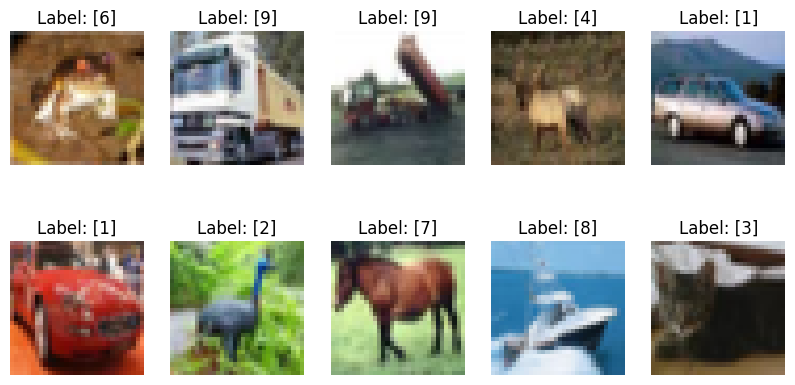

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

In [ ]:
x_train = x_train/255.0
x_test = x_test/255.0

In [ ]:
x_train = x_train.reshape(-1,32,32,3)
x_test = x_test.reshape(-1,32,32,3)

In [ ]:
print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [ ]:
y_train = to_categorical(y_train.flatten(), 10)
y_test = to_categorical(y_test.flatten(), 10)

In [ ]:
model = Sequential()

# layer 1
model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(32,32,3)))     #First Convolution Layer
model.add(MaxPooling2D(pool_size=(2,2)))                                               #First Pooling Layer

#layer 2
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))                            #Second Convolution Layer
model.add(MaxPooling2D(pool_size=(2,2)))                                               #Second Pooling Layer

#layer 3
model.add(Conv2D(128, kernel_size=(3,3), activation='relu'))                           #Third Convolution Layer
model.add(MaxPooling2D(pool_size=(2,2)))                                               #Third Pooling Layer

#Flatten Layer
model.add(Flatten())

#Fully Connected Layer
model.add(Dense(128, activation='relu'))

#Dropout Layer
model.add(Dropout(0.5))

#Output Layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train, batch_size=64, epochs=30, validation_split=0.2)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.3369 - loss: 1.7713 - val_accuracy: 0.4777 - val_loss: 1.4150
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.4925 - loss: 1.4033 - val_accuracy: 0.5601 - val_loss: 1.2312
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5548 - loss: 1.2489 - val_accuracy: 0.5894 - val_loss: 1.1798
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5992 - loss: 1.1369 - val_accuracy: 0.6101 - val_loss: 1.0824
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6308 - loss: 1.0531 - val_accuracy: 0.6445 - val_loss: 1.0111
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6566 - loss: 0.9825 - val_accuracy: 0.6670 - val_loss: 0.9546
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6778 - loss: 0.9231 - val_accuracy: 0.6861 - val_loss: 0.9004
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6962 - loss: 0.8702 - val_accuracy: 0.

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Loss", test_loss)
print("Test Accuracy", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7153 - loss: 1.1233
Test Loss 1.1233445405960083
Test Accuracy 0.7153000235557556


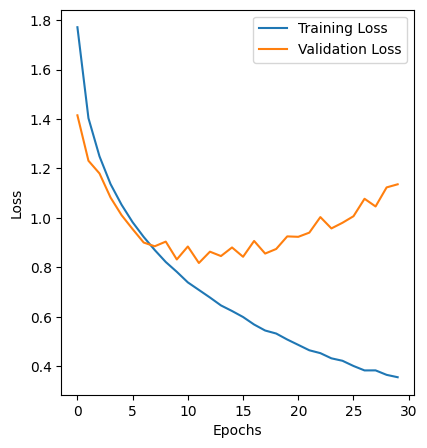

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

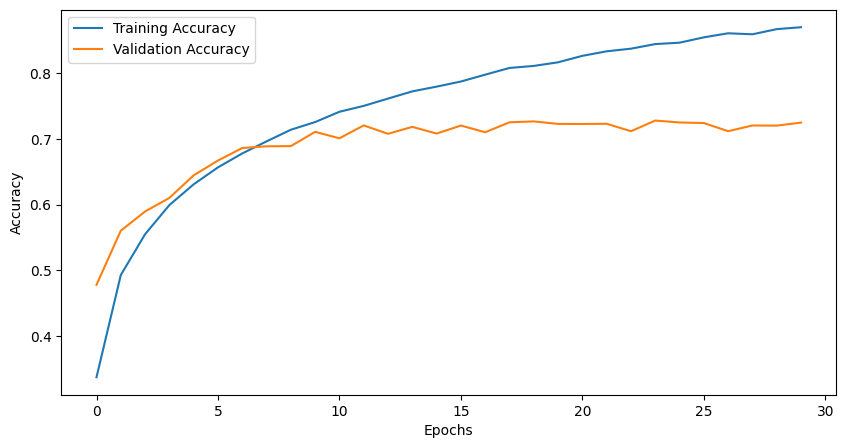

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


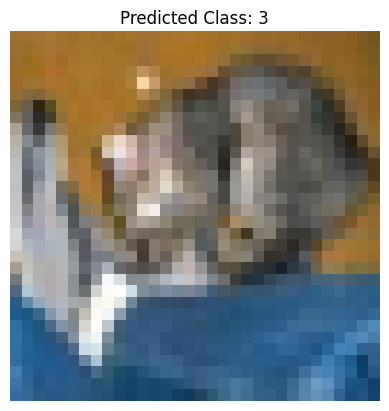

In [ ]:
sample = x_test[0]
prediction = model.predict(sample.reshape(1,32,32,3))
predicted_class = np.argmax(prediction)
plt.imshow(sample, cmap='gray')
plt.title(f"Predicted Class: {predicted_class}")
plt.axis('off')
plt.show()

Saving press-13sep23-01.jpg to press-13sep23-01 (2).jpg


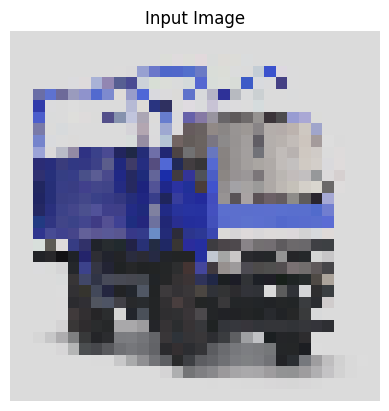

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Item: truck
Confidence Score 99.999916 %


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import cv2
uploaded = files.upload()
file_path = list(uploaded.keys())[0]
img = cv2.imread(file_path)
img = cv2.resize(img, (32,32))

#Normalize
img = img.astype("float32")/255.0


#Display
plt.imshow(img, cmap='gray')
plt.title("Input Image")
plt.axis('off')
plt.show()

#Reshape for CNN
img = np.expand_dims(img, axis=0)

#Predict
prediction = model.predict(img)
predicted_class = np.argmax(prediction)
print("Predicted Item:", class_names[predicted_class])

#Print the Confidence score
print("Confidence Score", np.max(prediction)*100,"%")